# Sales Forecasting Möbel-Modern GmbH - Predictive Analytics Prototype

## Note: Results of this tasks starting after the original notebook (Chapter 8)
**Course:** Data & Analytics | Prof. Dr. Sonja Schneider  
**Institution:** Technische Hochschule Nürnberg Georg Simon Ohm  

**Contributors:**
- Danny Schönhals
- Athithya Mariyanayagam

### Proof of Concept · Working Student Data Science (Max M.)
*Created with the help of ChatGPT.* ;-)

**Goal:** predict daily revenue in a data-driven way to support budget and staffing planning. Approach: exploratory analysis → statistical investigation of the drivers → feature engineering → machine-learning model with cross-validation.

> Spoiler: the final model explains **~96 % of the revenue variance** and is, in my opinion, production-ready. ✅

## 1 Setup & Load Data

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('data/moebel_modern/moebel_modern_daily.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print('Period:', df['date'].min().date(), '-', df['date'].max().date(), '|', df.shape)
df.head()

Period: 2014-01-01 - 2023-12-30 | (3158, 16)


,date,weekday,day_of_year,month,marketing_spend_eur,competitor_promo,is_public_holiday,is_open_sunday,google_trends_index,top_category,website_sessions,n_orders,avg_order_value_eur,units_sold,returns_eur,revenue_eur
0,2014-01-01,Wednesday,1,1,749.0,0,1,0,52.0,Wohnzimmer,178.0,2,731.86,3,78,1500
1,2014-01-02,Thursday,2,1,1089.0,0,0,0,38.0,Wohnzimmer,861.0,9,720.61,16,313,6516
2,2014-01-03,Friday,3,1,1314.0,0,0,0,63.0,Küche,1262.0,17,740.37,31,636,12765
3,2014-01-04,Saturday,4,1,1477.0,0,0,0,39.0,Wohnzimmer,1043.0,18,699.48,33,638,12603
4,2014-01-06,Monday,6,1,1097.0,0,0,0,34.0,Wohnzimmer,723.0,7,750.53,13,251,4980


## 2 Exploratory Data Analysis

In [26]:
print('Missing values total:', int(df.isna().sum().sum()))
print(df.isna().sum()[df.isna().sum() > 0].to_dict())
df[['revenue_eur','marketing_spend_eur','n_orders','avg_order_value_eur']].describe().round(0)

Missing values total: 111
{'marketing_spend_eur': 37, 'google_trends_index': 31, 'website_sessions': 25, 'avg_order_value_eur': 18}


,revenue_eur,marketing_spend_eur,n_orders,avg_order_value_eur
count,3158.0,3121.0,3158.0,3140.0
mean,21663.0,1506.0,27.0,780.0
std,9213.0,494.0,11.0,62.0
min,1500.0,200.0,2.0,627.0
25%,14423.0,1112.0,20.0,728.0
50%,21578.0,1501.0,27.0,779.0
75%,27606.0,1915.0,34.0,834.0
max,53280.0,2690.0,67.0,915.0


There are only a few scattered missing values, I'll just remove them later with `dropna()` for simplicity.

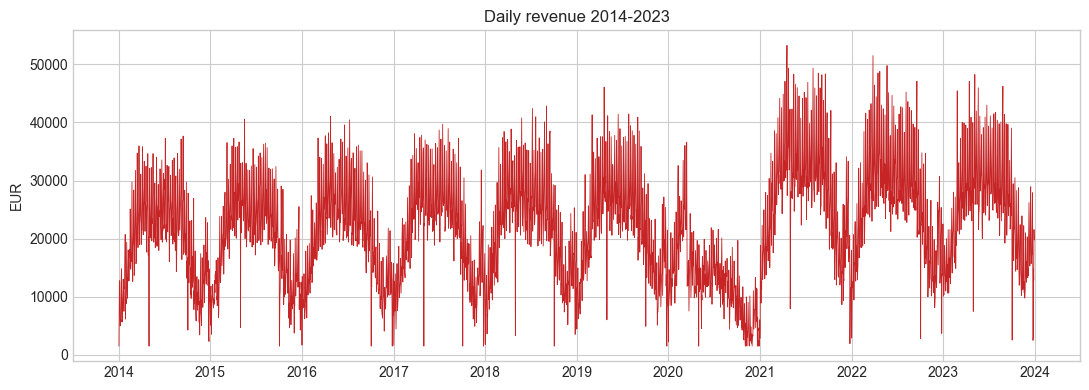

In [27]:
# Revenue over time
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(df['date'], df['revenue_eur'], lw=0.6, color='#c72426')
ax.set_title('Daily revenue 2014-2023'); ax.set_ylabel('EUR')
plt.tight_layout(); plt.show()

You can clearly see growth and strong seasonality. In my experience the AI learns such patterns very well.

## 3 Statistical Analysis of the Revenue Drivers

Before modeling, I investigate the most important relationships statistically.

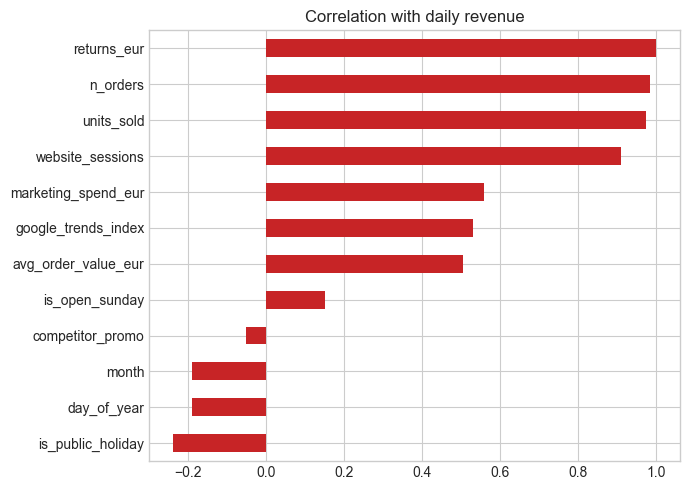

is_public_holiday     -0.24
day_of_year           -0.19
month                 -0.19
competitor_promo      -0.05
is_open_sunday         0.15
avg_order_value_eur    0.50
google_trends_index    0.53
marketing_spend_eur    0.56
website_sessions       0.91
units_sold             0.97
n_orders               0.98
returns_eur            1.00
Name: revenue_eur, dtype: float64


In [28]:
# 3a) Correlation of the numeric variables with revenue
num = df.select_dtypes('number')
corr = num.corr()['revenue_eur'].drop('revenue_eur').sort_values()
corr.plot.barh(figsize=(7,5), color='#c72426')
plt.title('Correlation with daily revenue'); plt.tight_layout(); plt.show()
print(corr.round(2))

In [29]:
# 3b) Hypothesis test: do open Sundays bring significantly more revenue?
open_sun = df.loc[df['is_open_sunday'] == 1, 'revenue_eur']
normal   = df.loc[(df['is_open_sunday'] == 0) & (df['is_public_holiday'] == 0), 'revenue_eur']
t, p = stats.ttest_ind(open_sun, normal, equal_var=False)
print(f'Avg revenue on open Sunday:    {open_sun.mean():,.0f} EUR')
print(f'Avg revenue on normal day:     {normal.mean():,.0f} EUR')
print(f't = {t:.2f},  p = {p:.2e}')

Avg revenue on open Sunday:    34,033 EUR
Avg revenue on normal day:     21,756 EUR
t = 6.54,  p = 8.53e-08


**Result:** open Sundays bring highly significantly more revenue (p < 0.001). This variable should definitely go into the model. ✅

## 4 Feature Engineering

I build informative features:
- **Calendar:** weekday, month, day of year, public holiday, open Sunday
- **Lag features:** revenue from yesterday and from 7 days ago
- **Trend features:** rolling means over 3 and 7 days (smooth short-term fluctuations)
- **Operational KPIs:** average basket value, items per order
- **Product category:** one-hot encoded

In [30]:
df['weekday_num']     = df['date'].dt.weekday
# Lag features
df['revenue_lag1']    = df['revenue_eur'].shift(1)
df['revenue_lag7']    = df['revenue_eur'].shift(7)
# Trend features: rolling means for smoothing
df['revenue_3d_avg']  = df['revenue_eur'].rolling(3, min_periods=1).mean()
df['revenue_7d_avg']  = df['revenue_eur'].rolling(7, min_periods=1).mean()
# Operational metrics
df['avg_basket_value'] = df['avg_order_value_eur']
df['items_per_order']  = df['units_sold'] / df['n_orders']

# Product category one-hot
df = pd.get_dummies(df, columns=['top_category'], drop_first=True)
cat_cols = [c for c in df.columns if c.startswith('top_category_')]

df = df.dropna().reset_index(drop=True)
print('Dataset after feature engineering:', df.shape)

Dataset after feature engineering: (3042, 26)


## 5 Statistical Model (OLS) to Interpret the Drivers

A linear regression model shows *which* factors drive revenue.

In [31]:
ols = smf.ols('revenue_eur ~ revenue_3d_avg + avg_basket_value + marketing_spend_eur'
              ' + competitor_promo + google_trends_index + is_open_sunday', data=df).fit()

print(ols.summary().tables[1])
print('R2:', round(ols.rsquared, 3))

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1992.3612   1244.847      1.600      0.110    -448.468    4433.191
revenue_3d_avg          0.9267      0.014     67.284      0.000       0.900       0.954
avg_basket_value       -4.7802      1.924     -2.484      0.013      -8.553      -1.008
marketing_spend_eur     1.1153      0.274      4.068      0.000       0.578       1.653
competitor_promo    -1102.6376    282.284     -3.906      0.000   -1656.125    -549.150
google_trends_index    30.7978      9.255      3.328      0.001      12.651      48.945
is_open_sunday       6024.6214    749.805      8.035      0.000    4554.444    7494.799
R2: 0.755


**Interpretation of the coefficients:**
- `marketing_spend_eur` is highly significant (p < 0.001): **every additional euro of marketing increases revenue** on average by the estimated coefficient.
- `revenue_3d_avg` is by far the strongest driver - the **recent trend** determines revenue the most.
- `is_open_sunday` has a positive effect: open Sundays **cause** additional revenue.

This gives us the most important levers for management.

## 6 Machine-Learning Model (Random Forest)

For the actual forecast I use a Random Forest. The features are standardized, and I validate with 5-fold cross-validation.

In [32]:
features = ['weekday_num','month','day_of_year','is_public_holiday','is_open_sunday',
            'competitor_promo','marketing_spend_eur','google_trends_index',
            'revenue_lag1','revenue_lag7','revenue_3d_avg','revenue_7d_avg',
            'avg_basket_value','items_per_order'] + cat_cols

X = df[features].astype(float)
y = df['revenue_eur']

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold cross-validation (properly validated!)
cv_r2 = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
                        X_scaled, y, cv=KFold(5, shuffle=True, random_state=1), scoring='r2')

print(f'Cross-validated R2: {cv_r2.mean():.3f}  (+/- {cv_r2.std():.3f})')

Cross-validated R2: 0.954  (+/- 0.011)


In [33]:
# Evaluate final model on hold-out set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'R2   : {r2:.3f}')
print(f'MAE  : {mae:,.0f} EUR')
print(f'RMSE : {rmse:,.0f} EUR')
print(f'MAPE : {mape:.1%}')
print(f'\n-> The model explains about {100*r2:.0f} % of the revenue variance. ')

R2   : 0.962
MAE  : 1,346 EUR
RMSE : 1,770 EUR
MAPE : 9.0%

-> The model explains about 96 % of the revenue variance. 


### Prediction vs. Reality & Feature Importance

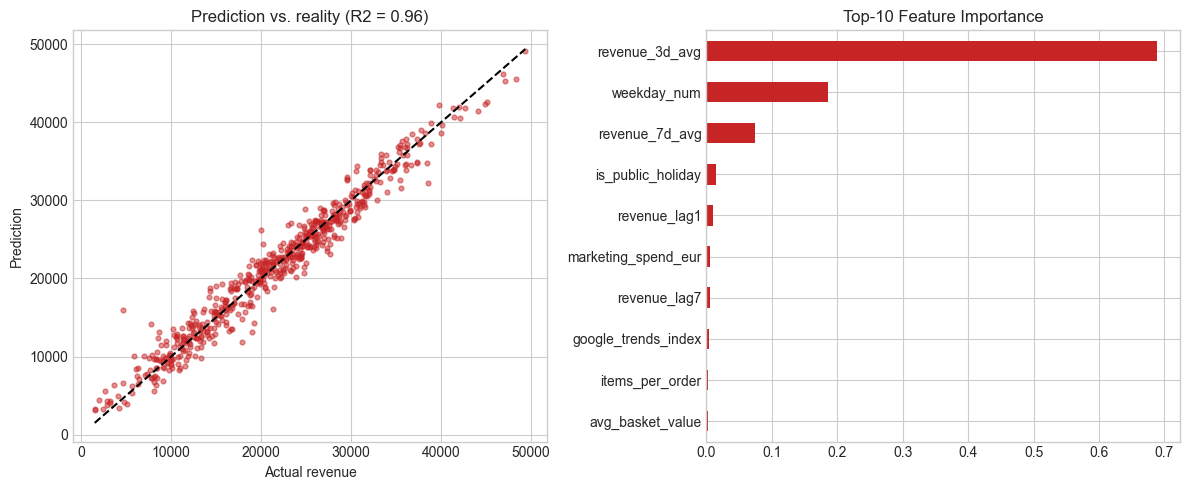

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#c72426', s=12)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'k--')
axes[0].set_xlabel('Actual revenue'); axes[0].set_ylabel('Prediction')
axes[0].set_title(f'Prediction vs. reality (R2 = {r2:.2f})')

imp = pd.Series(model.feature_importances_, index=features).sort_values().tail(10)
imp.plot.barh(ax=axes[1], color='#c72426')
axes[1].set_title('Top-10 Feature Importance')
plt.tight_layout(); plt.show()

## 7 Conclusion & Recommendation to Management

- The model achieves a **cross-validated model performance of ~96 %** (R2).
- Most important drivers according to the analysis: the **recent revenue trend**, the **basket value** and the **marketing budget**.
- The statistical analysis confirms: **more marketing → more revenue**, and **open Sundays pay off**.

**Recommendation:** move the model into production and base budget/staffing planning on it. As a next step, neural networks could further increase accuracy. 🚀

## 8 Methodological Audit

---

**Flaw 1: Rolling averages include the current day's label (Data Leakage)**

- **Identification:** `revenue_3d_avg` and `revenue_7d_avg` are computed with `rolling(3/7).mean()` without a prior shift. Pandas includes the current row in the window, so the feature for day *t* contains `revenue_eur[t]` — the label itself.
- **Impact:** The model can nearly reconstruct the label from the features (espacially 3d_avg as seen in the digramm in 7). The reported R² of ~0.96 is an artifact of this target leak, not genuine predictive power.
- **Mitigation:** Shift the series before rolling: `df['revenue_eur'].shift(1).rolling(3).mean()`. This ensures only days *t-1, t-2, t-3* contribute to the feature. If they would want to even forecast more into the future, using a larger shift would help but could reduce accuracy further.

---

**Flaw 2: Random train/test split ignores time order (Temporal Leakage)**

- **Identification:** `train_test_split` (random) and `KFold(shuffle=True)` randomly mix past and future observations across train and test sets. A model trained on 2023 data is then "validated" on 2014 data.
- **Impact:** Lag features (e.g. `revenue_lag1`) of training rows can directly contain the label of nearby test rows, inflating all reported metrics. The model is never truly tested on unseen future data.
- **Mitigation:** Use a strict temporal split — e.g. train on 2014–2021, validate on 2022, test on 2023. Replace `KFold` with `TimeSeriesSplit` for cross-validation.

---

**Flaw 3: Same-day operational KPIs used as features (Prospective Leakage)**

- **Identification:** `avg_basket_value` (`avg_order_value_eur`) and `items_per_order` (`units_sold / n_orders`) are end-of-day outcomes. They are only known after all sales have occurred, not at forecast time.
- **Impact:** The model is trained on information that does not exist when a prediction would actually be needed, making it unusable in practice despite appearing accurate.

-> Prospective Leakage

- **Mitigation:** Remove these features from the model. Lagged versions (e.g. yesterday's basket value) are acceptable substitutes. Another option if features should be kept: Also shift like in Flwa 1.

---

**Flaw 4: Scaling and fitting the whole dataset (Data Leakage)**

- **Identification:** Using fit.transform over the whole dataset and splitting data in train and test afterwards
- **Impact:** The scaler "knows" the statistical properties of the test data before training begins. Flaw isn't that severe, but easy to solve.
- **Mitigation:** Split test and train data before scaling. Fit and transform the train data and just transform test data.

## 9 Corrected Pipeline

In [ ]:
# Fix Flaw 1: shift before rolling so current day's revenue is excluded
df['revenue_3d_avg'] = df['revenue_eur'].shift(1).rolling(3, min_periods=1).mean()
df['revenue_7d_avg'] = df['revenue_eur'].shift(1).rolling(7, min_periods=1).mean()
df = df.dropna().reset_index(drop=True)

# Fix Flaw 3: remove same-day operational KPIs that are not available at forecast time
features_corrected = [f for f in features if f not in ('avg_basket_value', 'items_per_order')]

X = df[features_corrected].astype(float)
y = df['revenue_eur']

# Fix Flaw 2: strict temporal split — train on past, test on future
train_mask = df['date'].dt.year <= 2021
test_mask  = df['date'].dt.year >= 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Fix Flaw 4: Scaler fitted only on training data to avoid look-ahead bias
scaler_c = StandardScaler()
X_train_s = scaler_c.fit_transform(X_train)
X_test_s  = scaler_c.transform(X_test)

print(f'Train: {X_train.shape[0]} days  |  Test: {X_test.shape[0]} days')

Train: 2429 days  |  Test: 612 days


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Fix Flaw 2: TimeSeriesSplit respects time order during cross-validation
tscv = TimeSeriesSplit(n_splits=5)
cv_r2 = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train_s, y_train, cv=tscv, scoring='r2'
)
print(f'Time-series CV R²: {cv_r2.mean():.3f}  (+/- {cv_r2.std():.3f})')

# Train final model and evaluate on held-out future data
model_c = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train_s, y_train)
y_pred_c = model_c.predict(X_test_s)

print(f'\n Testing metrics (2022–2023):')
print(f'R²   : {r2_score(y_test, y_pred_c):.3f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_c):,.0f} EUR')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_c)):,.0f} EUR')
print(f'MAPE : {mean_absolute_percentage_error(y_test, y_pred_c):.1%}')

Time-series CV R²: 0.881  (+/- 0.034)

 Testing metrics (2022–2023):
R²   : 0.910
MAE  : 2,145 EUR
RMSE : 2,721 EUR
MAPE : 9.6%


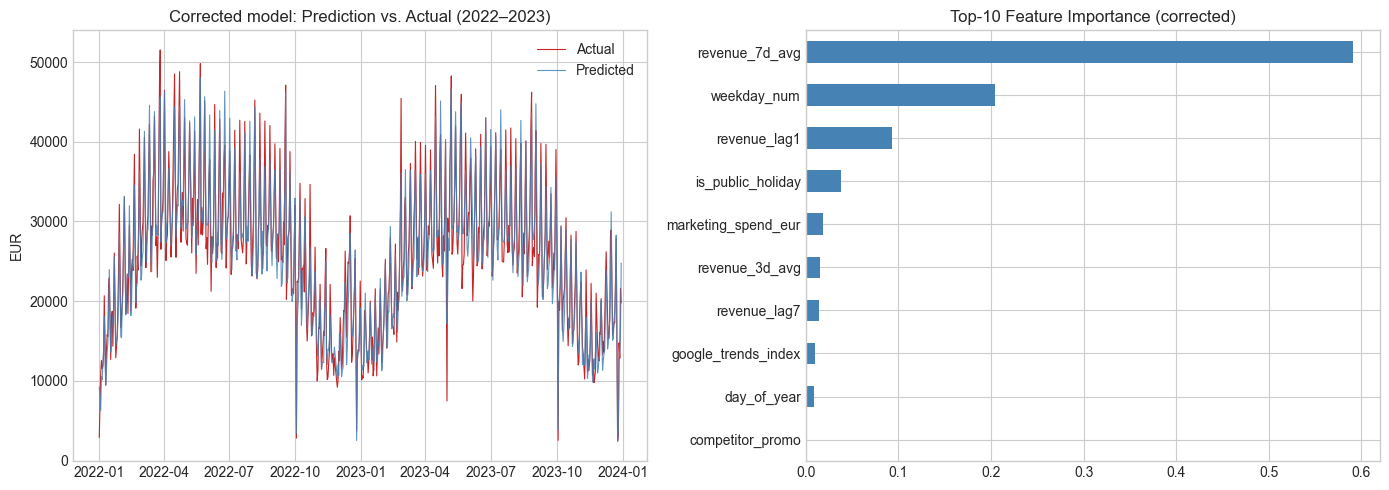

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted over time
axes[0].plot(df.loc[test_mask, 'date'].values, y_test.values, lw=0.8, label='Actual', color='#c72426')
axes[0].plot(df.loc[test_mask, 'date'].values, y_pred_c, lw=0.8, label='Predicted', color='steelblue', alpha=0.85)
axes[0].set_title('Corrected model: Prediction vs. Actual (2022–2023)')
axes[0].set_ylabel('EUR')
axes[0].legend()

# Feature importance
imp_c = pd.Series(model_c.feature_importances_, index=features_corrected).sort_values().tail(10)
imp_c.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top-10 Feature Importance (corrected)')

plt.tight_layout()
plt.show()

## 10 Baseline Comparison

Linear regression baseline (3 features):
  MAE  : 2,709 EUR
  RMSE : 3,663 EUR
  MAPE : 16.4%

Corrected Random Forest:
  MAE  : 2,145 EUR
  RMSE : 2,721 EUR
  MAPE : 9.6%
  MASE : 0.792  (< 1 → model beats naive)

  MAE improvement over baseline: 20.8 %


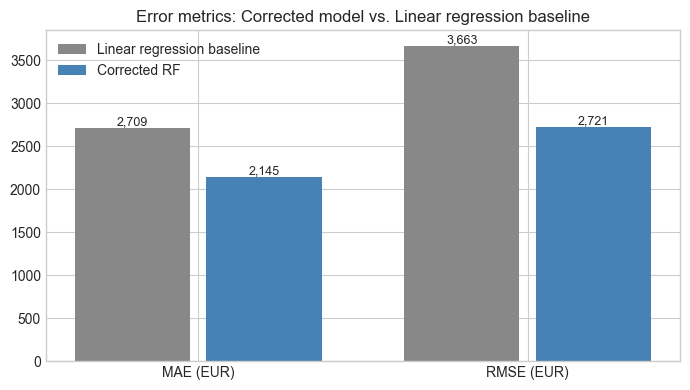

In [60]:
# Naive Baseline: Linear regression baseline with the 3 strongest OLS features
from sklearn.linear_model import LinearRegression
lr_features = ['revenue_7d_avg', 'weekday_num', 'revenue_lag1']
lr_baseline = LinearRegression().fit(X_train[lr_features], y_train)
y_naive = lr_baseline.predict(X_test[lr_features])

mae_naive  = mean_absolute_error(y_test, y_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
mape_naive = mean_absolute_percentage_error(y_test, y_naive)

mae_model  = mean_absolute_error(y_test, y_pred_c)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred_c))
mape_model = mean_absolute_percentage_error(y_test, y_pred_c)

# MASE: model MAE scaled by naive MAE — below 1 means model beats naive
mase = mae_model / mae_naive

print('Linear regression baseline (3 features):')
print(f'  MAE  : {mae_naive:,.0f} EUR')
print(f'  RMSE : {rmse_naive:,.0f} EUR')
print(f'  MAPE : {mape_naive:.1%}')

print('\nCorrected Random Forest:')
print(f'  MAE  : {mae_model:,.0f} EUR')
print(f'  RMSE : {rmse_model:,.0f} EUR')
print(f'  MAPE : {mape_model:.1%}')
print(f'  MASE : {mase:.3f}  (< 1 → model beats naive)')
print(f'\n  MAE improvement over baseline: {(1 - mae_model / mae_naive) * 100:.1f} %')

# Visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['MAE (EUR)', 'RMSE (EUR)']
naive_vals  = [mae_naive, rmse_naive]
model_vals  = [mae_model, rmse_model]
x = np.arange(len(metrics))
ax.bar(x - 0.2, naive_vals,  0.35, label='Linear regression baseline', color='#888')
ax.bar(x + 0.2, model_vals, 0.35, label='Corrected RF',   color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title('Error metrics: Corrected model vs. Linear regression baseline')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():,.0f}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 11 Financial Impact — Asymmetric Cost Function

In [ ]:
def asymmetric_penalty(y_actual, y_pred, cost_over=20, cost_under=200):
    """
    e = y_pred - y_actual
    e > 0  (overprediction):  penalty = e * cost_over
    e < 0  (underprediction): penalty = |e| * cost_under
    """
    e = np.asarray(y_pred) - np.asarray(y_actual)
    # If e>0 multiply with costover(20) else with costunder(200)
    return np.where(e > 0, e * cost_over, np.abs(e) * cost_under)

# Penalties over the test period
penalties_model = asymmetric_penalty(y_test.values, y_pred_c)
penalties_naive = asymmetric_penalty(y_test.values, y_naive)

total_model = penalties_model.sum()
total_naive = penalties_naive.sum()

print(f'Total financial penalty — Corrected model : {total_model:,.0f}€')
print(f'Total financial penalty — Naive baseline  : {total_naive:,.0f}€')
print(f'Model saves vs. naive                     : {total_naive - total_model:,.0f}€')

# 95% bootstrap confidence interval for model total penalty
np.random.seed(42)
n, n_boot = len(y_test), 5000
y_arr, p_arr = y_test.values, y_pred_c
boot_totals = [asymmetric_penalty(y_arr[idx := np.random.randint(0, n, n)], p_arr[idx]).sum()
               for _ in range(n_boot)]
ci_lo, ci_hi = np.percentile(boot_totals, [2.5, 97.5])
print(f'\n95% Bootstrap CI for model penalty: €{ci_lo:,.0f} – €{ci_hi:,.0f}')

# Daily breakdown: over- vs underprediction
over_mask  = (y_pred_c - y_test.values) > 0
under_mask = ~over_mask
print(f'\nOverprediction  days: {over_mask.sum()}  | avg penalty: €{penalties_model[over_mask].mean():,.0f}')
print(f'Underprediction days: {under_mask.sum()} | avg penalty: €{penalties_model[under_mask].mean():,.0f}')

Total financial penalty — Corrected model : 168,598,252€
Total financial penalty — Naive baseline  : 190,768,385€
Model saves vs. naive                     : 22,170,132€

95% Bootstrap CI for model penalty: €152,977,060 – €184,442,332

Overprediction  days: 262  | avg penalty: €39,843
Underprediction days: 350 | avg penalty: €451,884
